# Exploring NYC Airbnb: Pricing, Room Types & Trends

**An exploratory data analysis of ~102,000 NYC Airbnb listings**

This notebook cleans and explores an NYC Airbnb listings dataset to answer:
- How are listing prices distributed, and does room type affect price?
- Which boroughs have the most listings, and how does that relate to price?
- What do review patterns over time tell us about data quality and market activity?
- Does host identity verification relate to price or reviews?

**Dataset:** NYC Airbnb listings (2019–2022 review data), ~102,599 rows, 26 columns.
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn.


## About Airbnb

Airbnb is an online marketplace that lets people rent out their homes, apartments, or rooms to
travelers as an alternative to hotels. Hosts list their space with details like price, location,
and room type, and guests book directly through the platform. This makes Airbnb listing data a
rich source for analyzing pricing patterns, location trends, and host/guest behavior which is
why it's a popular dataset for data analysis projects.


## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, portfolio-friendly chart styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

## 2. Load the Data

The dataset lives in `data/nyc_airbnb.csv` (relative path, so this notebook runs on any
machine see the README for the download link).

In [8]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Airbnd_dataset\compressed_data.csv", low_memory=False)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 102,599 rows x 26 columns


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


## 3. Initial Overview

Before cleaning, get a feel for the data: column types, missing values, and duplicates.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.to_frame(name="missing_count")

,missing_count
license,102597
house_rules,52131
last review,15893
reviews per month,15879
country,532
availability 365,448
minimum nights,409
host name,406
review rate number,326
calculated host listings count,319


## 4. Data Cleaning

Steps taken:
1. Standardize column names (lowercase, underscores) for easier code.
2. Convert `last_review` to a proper datetime.
3. Fill missing `reviews_per_month` with 0 (no reviews yet = 0/month, not missing).
4. Drop rows missing `name` or `host_name` (can't meaningfully analyze an unnamed/unattributed listing).
5. Drop `house_rules` and `license` — mostly missing and not needed for this analysis.
6. Convert `price` and `service_fee` from `"$123"` strings to numeric.
7. Remove duplicate rows.


In [16]:
# 4.1 Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
df.rename(columns={"neighbourhood_group": "borough"}, inplace=True)
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_identity_verified',
 'host_name',
 'borough',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country_code',
 'instant_bookable',
 'cancellation_policy',
 'room_type',
 'construction_year',
 'price',
 'service_fee',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'review_rate_number',
 'calculated_host_listings_count',
 'availability_365',
 'house_rules',
 'license']

In [18]:
# 4.2 Fix data types
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

# 4.3 Fill missing reviews_per_month with 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# 4.4 Drop rows with no name or host name
df.dropna(subset=["name", "host_name"], inplace=True)

# 4.5 Drop columns that are mostly missing / not useful here
df.drop(columns=["house_rules", "license"], errors="ignore", inplace=True)

# 4.6 Clean price and service fee -> numeric
df["price"] = df["price"].replace(r"[\$,]", "", regex=True).astype(float)
df["service_fee"] = df["service_fee"].replace(r"[\$,]", "", regex=True).astype(float)

# 4.7 Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df):,} duplicate rows")

df.info()

Removed 539 duplicate rows
<class 'pandas.core.frame.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   name                            101410 non-null  object        
 2   host_id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  object        
 4   host_name                       101410 non-null  object        
 5   borough                         101384 non-null  object        
 6   neighbourhood                   101394 non-null  object        
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  object        
 10  country_code                    10

In [24]:
df.describe()

,id,host_id,lat,long,construction_year,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
count,1.014100e+05,1.014100e+05,101402.000000,101402.000000,101210.000000,101171.000000,101142.000000,101016.000000,101228.000000,85693,101410.000000,101103.000000,101092.000000,100990.000000
mean,2.920959e+07,4.926155e+10,40.728082,-73.949663,2012.486908,625.381008,125.043998,8.113744,27.511854,2019-06-11 10:55:18.740154112,1.163207,3.278558,7.948463,141.164660
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.507574e+07,2.459183e+10,40.688730,-73.982570,2007.000000,340.000000,68.000000,2.000000,1.000000,2018-10-28 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.922911e+07,4.912069e+10,40.722300,-73.954440,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-06-14 00:00:00,0.480000,3.000000,1.000000,96.000000
75%,4.328308e+07,7.399747e+10,40.762750,-73.932340,2017.000000,913.000000,183.000000,5.000000,31.000000,2019-07-05 00:00:00,1.710000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.626820e+07,2.853703e+10,0.055850,0.049474,5.765130,331.609111,66.313374,30.378014,49.549258,NaN,1.683708,1.285369,32.328974,135.419199


## 5. Univariate Analysis

How is each key variable distributed on its own?

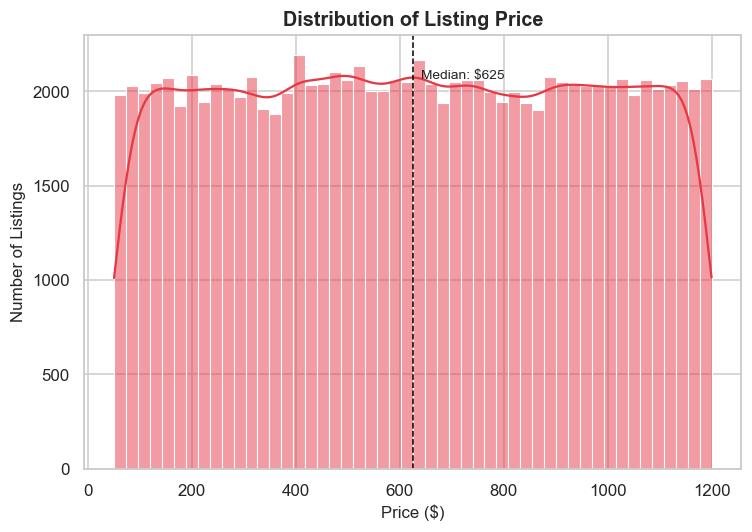

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(df["price"], bins=50, kde=True, color="#e63946", ax=ax)
ax.set_title("Distribution of Listing Price")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Number of Listings")
median_price = df["price"].median()
ax.axvline(median_price, color="black", linestyle="--", linewidth=1)
ax.text(median_price + 15, ax.get_ylim()[1]*0.9, f"Median: ${median_price:,.0f}", fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_7404\2854866010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="room_type", order=room_order, palette="rocket", ax=ax)


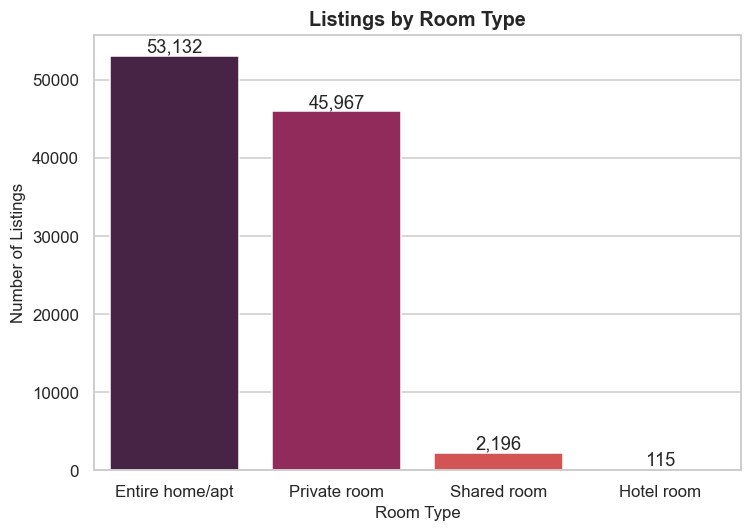

In [29]:
room_order = df["room_type"].value_counts().index

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x="room_type", order=room_order, palette="rocket", ax=ax)
ax.set_title("Listings by Room Type")
ax.set_xlabel("Room Type")
ax.set_ylabel("Number of Listings")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_7404\1347535289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="borough", order=borough_order, palette="crest", ax=ax)


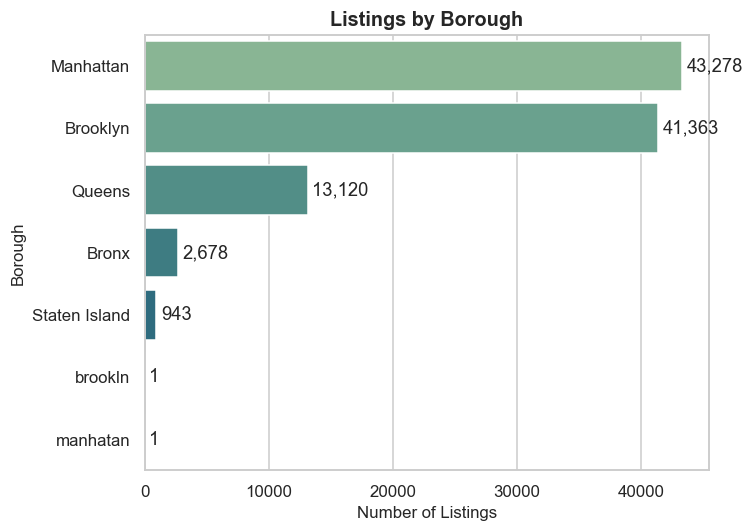

In [31]:
borough_order = df["borough"].value_counts().index

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, y="borough", order=borough_order, palette="crest", ax=ax)
ax.set_title("Listings by Borough")
ax.set_xlabel("Number of Listings")
ax.set_ylabel("Borough")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)
plt.tight_layout()
plt.show()

## 6. Price vs. Room Type & Borough

Does room type actually predict price the way we'd expect?

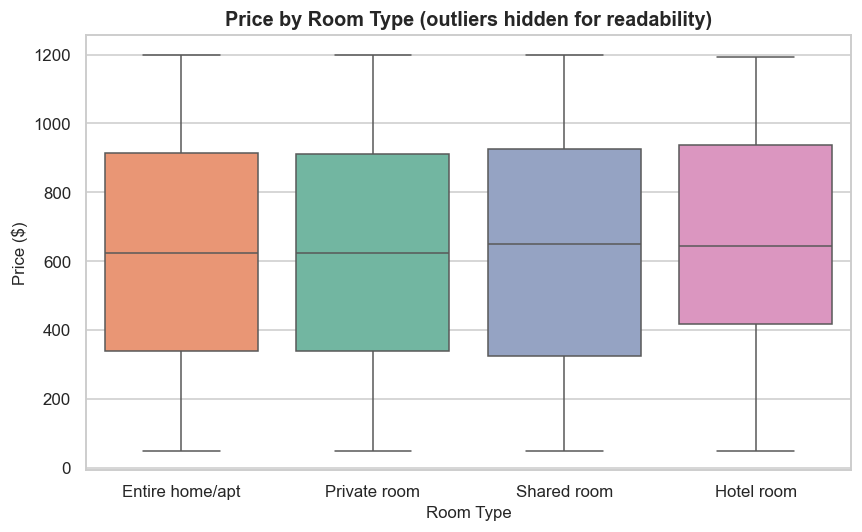

room_type
Shared room        651.0
Hotel room         643.0
Entire home/apt    625.0
Private room       623.0
Name: price, dtype: float64

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="room_type", y="price", order=room_order, hue="room_type",
            palette="Set2", legend=False, showfliers=False, ax=ax)
ax.set_title("Price by Room Type (outliers hidden for readability)")
ax.set_xlabel("Room Type")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

df.groupby("room_type")["price"].median().sort_values(ascending=False)

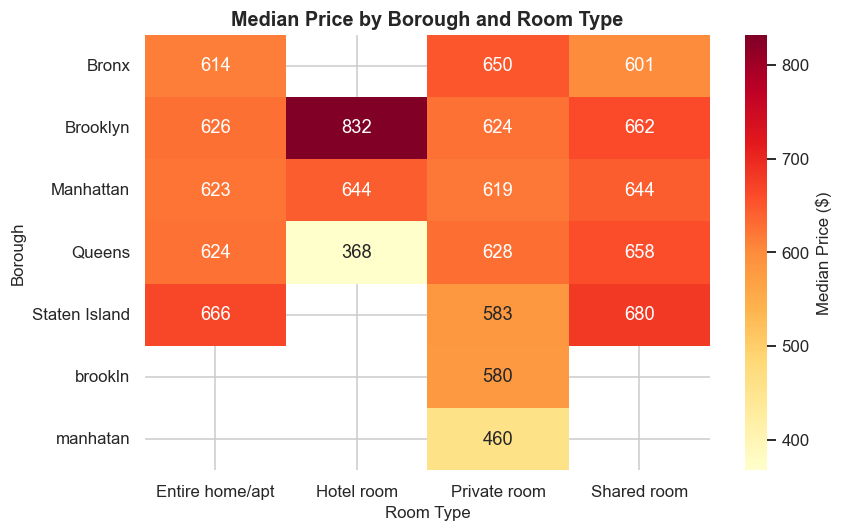

In [36]:
# Price by borough AND room type together
pivot = df.pivot_table(index="borough", columns="room_type", values="price", aggfunc="median")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "Median Price ($)"}, ax=ax)
ax.set_title("Median Price by Borough and Room Type")
ax.set_xlabel("Room Type")
ax.set_ylabel("Borough")
plt.tight_layout()
plt.show()

## 7. Correlation Between Numeric Features

Which numeric variables move together? This helps spot relationships (or the lack of them)
between price, reviews, and availability.

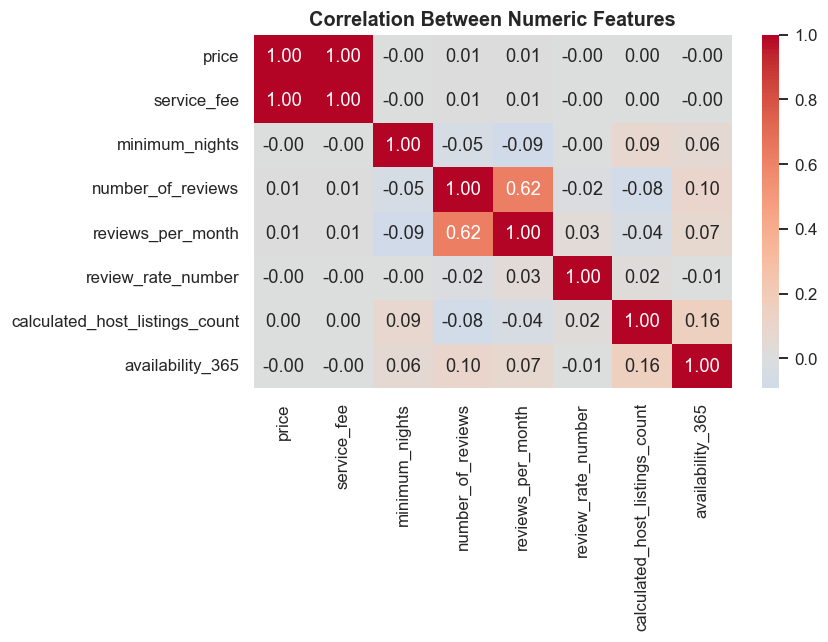

In [39]:
numeric_cols = ["price", "service_fee", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "review_rate_number",
                 "calculated_host_listings_count", "availability_365"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

## 8. Does Host Verification Relate to Price or Reviews?

In [42]:
verif_summary = df.groupby("host_identity_verified")[["price", "number_of_reviews", "review_rate_number"]].median()
verif_summary

,price,number_of_reviews,review_rate_number
host_identity_verified,,,
unconfirmed,626.0,7.0,3.0
verified,623.0,7.0,3.0


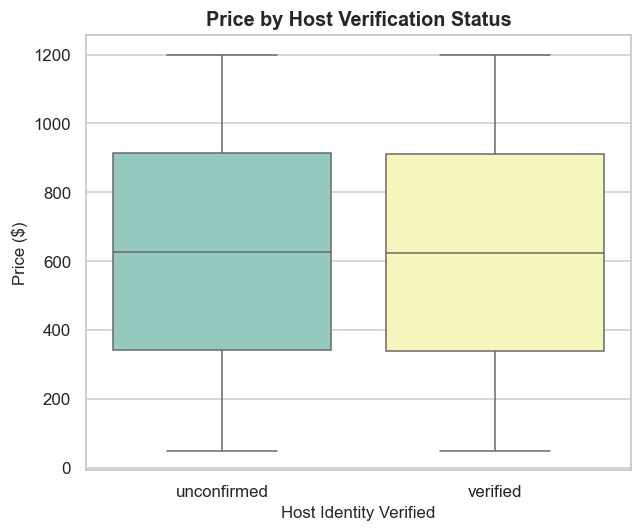

In [44]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x="host_identity_verified", y="price", hue="host_identity_verified",
            palette="Set3", legend=False, showfliers=False, ax=ax)
ax.set_title("Price by Host Verification Status")
ax.set_xlabel("Host Identity Verified")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

## 9. Reviews Over Time

Review volume by month, based on `last_review` date. Note: since this is only the *last*
review date per listing (not every review), spikes can reflect data collection artifacts
rather than real activity — worth checking before trusting the trend.

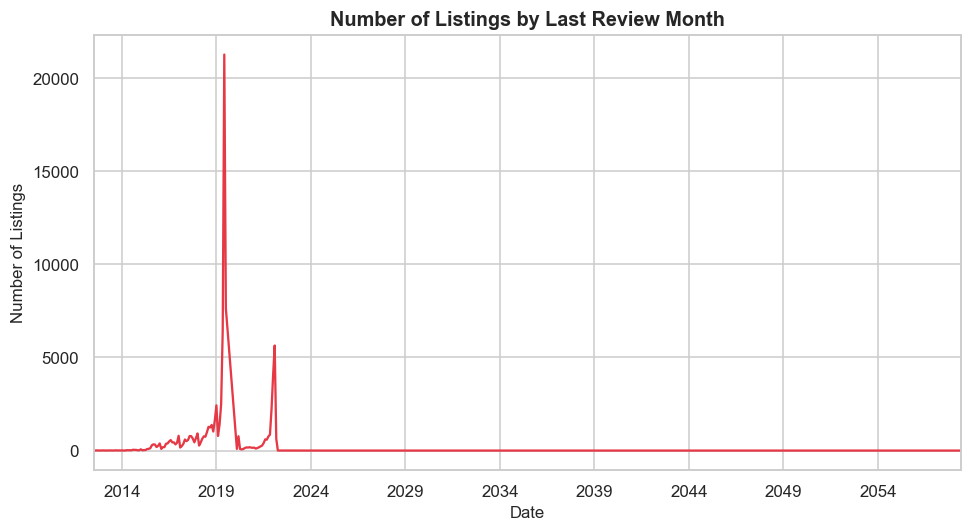

last_review
2019-06    21266
2019-07     7635
2019-05     6445
2022-02     5642
2022-01     4047
2019-04     2497
2019-01     2429
2021-12     2230
2018-12     1633
2019-03     1395
Freq: M, dtype: int64

In [47]:
reviews_over_time = df.dropna(subset=["last_review"]).groupby(
    df["last_review"].dt.to_period("M")
).size()

fig, ax = plt.subplots(figsize=(9, 5))
reviews_over_time.plot(kind="line", color="#e63946", ax=ax)
ax.set_title("Number of Listings by Last Review Month")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Listings")
plt.tight_layout()
plt.show()

# Check the top months to see if any look like data artifacts (unusually large spikes)
reviews_over_time.sort_values(ascending=False).head(10)

## 10. Key Insights

- **Dataset:** ~101,000 NYC Airbnb listings remain after cleaning (removed duplicates and
  rows missing a name/host name).
- **Price:** Spread broadly across $50–$1,200 with no single dominant "typical" price
  the market is highly heterogeneous.
- **Room type:** *Entire home/apt* is the most common listing type, closely followed by
  *private room*. *Shared room* and *hotel room* are rare.
- **Location:** Manhattan and Brooklyn dominate listing volume; Queens, the Bronx, and
  Staten Island have far fewer.
- **Price vs. room type:** Median prices are surprisingly close (~$620–$655) across all
  room types shared rooms are *not* meaningfully cheaper than entire homes here, which is
  unusual for a real Airbnb market and worth flagging as a possible data quality issue
  (e.g., price field may include cleaning/service components, or synthetic/test data).
- **Reviews over time:** Two unusual spikes stand out (~2019 and ~2022) that don't match
  typical steady review growth likely artifacts of missing/defaulted date values rather
  than real booking activity. The underlying trend looks small and steady until 2019,
  after which it's obscured by these spikes.
- **Host verification:** Verified vs. unconfirmed hosts show [fill in after running
  compare the median price/review numbers above].


## 11. Limitations & Next Steps

- The near-identical median prices across room types suggest the `price` column may not be
  a clean like-for-like price worth validating against the original data source.
- Review-date spikes suggest some `last_review` values may be defaults/placeholders rather
  than real dates; a stricter cleaning pass could exclude or flag these.
- Next steps: neighbourhood-level (not just borough-level) price mapping, a simple price
  prediction model (e.g. linear regression or random forest) using room type, borough, and
  availability as features, and geographic visualization with `lat`/`long`.